In [1]:
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
df = pd.read_excel("/content/Restaurant Reviews.csv.xlsx")
df.head()

,Review
0,Wow... Loved this place.
1,Crust is not good.
2,Not tasty and the texture was just nasty.
3,Stopped by during the late May bank holiday of...
4,The selection on the menu was great and so wer...


In [3]:
df.describe()

,Review
count,2216
unique,1606
top,The restaurant had clean and well-maintained f...
freq,31


In [4]:
df.isnull().sum()

,0
Review,4


In [5]:
df = df.dropna(subset=['Review'])

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)

In [7]:
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):
    score = sia.polarity_scores(str(review))
    compound = score['compound']

    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Use original review for sentiment detection
df['Sentiment'] = df['Review'].apply(analyze_sentiment)

print("Restaurant Reviews with Sentiment")
print(df[['Review', 'Sentiment']].head(20))

Restaurant Reviews with Sentiment
                                               Review Sentiment
0                            Wow... Loved this place.  Positive
1                                  Crust is not good.  Negative
2           Not tasty and the texture was just nasty.  Negative
3   Stopped by during the late May bank holiday of...  Positive
4   The selection on the menu was great and so wer...  Positive
5      Now I am getting angry and I want my damn pho.  Negative
6                Honeslty it didn't taste THAT fresh.  Negative
7   The potatoes were like rubber and you could te...  Positive
8                           The fries were great too.  Positive
9                                      A great touch.  Positive
10                           Service was very prompt.   Neutral
11                                 Would not go back.   Neutral
12  The cashier had no care what so ever on what I...  Positive
13  I tried the Cape Cod ravoli, chicken, with cra...   Neutral
14  I 

In [8]:
print("\nSentiment Distribution")
print(df['Sentiment'].value_counts())


Sentiment Distribution
Sentiment
Positive    971
Neutral     657
Negative    588
Name: count, dtype: int64


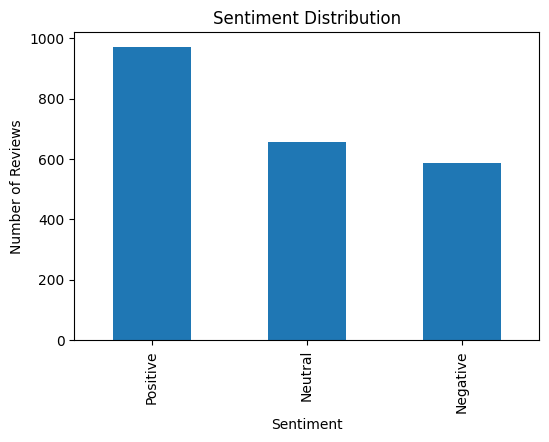

In [9]:
plt.figure(figsize=(6,4))

df['Sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

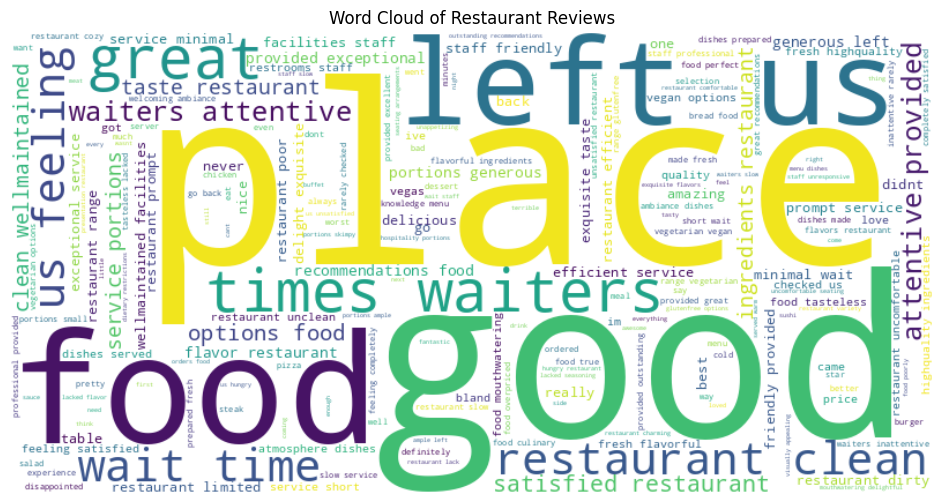

In [10]:
all_reviews = " ".join(df['Cleaned_Review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Restaurant Reviews')
plt.show()